# Steane Basic Level Noise (single round)

Data generation and analysis
    + different decoder: ML, MWPM
    + different distances
    + different noise levels

analysis: 
    + show asymptotic behavior
    + determine thresholds


In [36]:
import os
import numpy as np

from tools.file import read_config, write_config, read_folder, get_standard_config
from tools.combined import generate_new_data_from_config_file
from tools.analysis import data_pre_processing, determine_threshold, data_plot_log_error_rates, data_plot_fssa_results

from tools.parameter import PATH_TO_CONFIG_FOLDER

## Config Defintions and Data Generation

Steane circ (order 0p) with only 1 QEC round (both log X and Z observable)

Basic noise with different noise levels

Decoding both in ML and MWPM


In [37]:
# General parameter
noise_rates = [float(x) for x in np.logspace(-1.2,-0.8,dtype=float)]
distances = [5,7,9,11,13,15]
qec_rounds = [1,]
order = "0p"
circuit_type = "steane"

# Main parameters
num_shots_ML = 10_000
decoder_type_ML = "ml"
# 30 min
# 700 min + for 100_000 data
num_shots_MWPM = 100_000
decoder_type_MWPM = "mwpm"

# Z config
noise_model_type_Z = "bit_flip"
observable_Z  = "Z"
init_state_Z = "0"
# X config
noise_model_type_X = "phase_flip"
observable_X  = "X"
init_state_X = "p"

In [38]:
rerun_everything = False 
rerun_MWPM = False 

In [39]:
# ML Config (Z)
folder_name_ML_Z = "basic_md_1r_steane_Z_ML"

# Verbose is better!
config_ML_Z = {
    "circuit": {
        "distances":    distances, 
        "qec_rounds":   qec_rounds, 
        "observable":   observable_Z,   
        # not yet implemented
        "order":        order, 
        "type":         circuit_type, 
        # redundant:
        "inital_state": init_state_Z,
        "special_parameter": {},
    },
    "noise_model": {
        "type":         noise_model_type_Z,
        "noise_rates":  noise_rates,
        "special_parameter": {},        # open for future references
    },
    "decoder": {
        "type":         decoder_type_ML, 
    },
    "sampling": {
        "num_shots":    num_shots_ML,       # number of shots per configuration
    },
}
        
# write config to file
write_config(config_ML_Z,folder_name_ML_Z,backup=True)

In [40]:
# Generate ML Data
if rerun_everything or False:
    config_path = os.path.join(PATH_TO_CONFIG_FOLDER, folder_name_ML_Z + ".yaml")
    generate_new_data_from_config_file(config_path,output_folder_name=folder_name_ML_Z)

In [41]:
# ML Config (X)
folder_name_ML_X = "basic_md_1r_steane_X_ML"

config_ML_X = {
    "circuit": {
        "distances":    distances, 
        "qec_rounds":   qec_rounds, 
        "observable":   observable_X,   
        # not yet implemented
        "order":        order, 
        "type":         circuit_type, 
        # redundant:
        "inital_state": init_state_X,
        "special_parameter": {},
    },
    "noise_model": {
        "type":         noise_model_type_X,
        "noise_rates":  noise_rates,
        "special_parameter": {},        # open for future references
    },
    "decoder": {
        "type":         decoder_type_ML, 
    },
    "sampling": {
        "num_shots":    num_shots_ML,       # number of shots per configuration
    },
}

# write config to file
write_config(config_ML_X,folder_name_ML_X,backup=True)

In [42]:
# Generate ML Data
if rerun_everything or False:
    config_path = os.path.join(PATH_TO_CONFIG_FOLDER, folder_name_ML_X + ".yaml")
    generate_new_data_from_config_file(config_path,output_folder_name=folder_name_ML_X)

In [43]:
# MWPM Config (Z)
folder_name_MWPM_Z = "basic_md_1r_steane_Z_MWPM"

config_MWPM_Z = {
    "circuit": {
        "distances":    distances, 
        "qec_rounds":   qec_rounds, 
        "observable":   observable_Z,   
        # not yet implemented
        "order":        order, 
        "type":         circuit_type, 
        # redundant:
        "inital_state": init_state_Z,
        "special_parameter": {},
    },
    "noise_model": {
        "type":         noise_model_type_Z,
        "noise_rates":  noise_rates,
        "special_parameter": {},        # open for future references
    },
    "decoder": {
        "type":         decoder_type_MWPM, 
    },
    "sampling": {
        "num_shots":    num_shots_MWPM,       # number of shots per configuration
    },
}

# write config to file
write_config(config_MWPM_Z,folder_name_MWPM_Z,backup=True)

In [44]:
# Generate MWPM data
if rerun_everything or rerun_MWPM or False:
    config_path = os.path.join(PATH_TO_CONFIG_FOLDER, folder_name_MWPM_Z + ".yaml")
    generate_new_data_from_config_file(config_path,output_folder_name=folder_name_MWPM_Z)

In [45]:
# MWPM Config (X)
folder_name_MWPM_X = "basic_md_1r_steane_X_MWPM"

config_MWPM_X = {
    "circuit": {
        "distances":    distances, 
        "qec_rounds":   qec_rounds, 
        "observable":   observable_X,   
        # not yet implemented
        "order":        order, 
        "type":         circuit_type, 
        # redundant:
        "inital_state": init_state_X,
        "special_parameter": {},
    },
    "noise_model": {
        "type":         noise_model_type_X,
        "noise_rates":  noise_rates,
        "special_parameter": {},        # open for future references
    },
    "decoder": {
        "type":         decoder_type_MWPM, 
    },
    "sampling": {
        "num_shots":    num_shots_MWPM,     
    },
}

# write config to file
write_config(config_MWPM_X,folder_name_MWPM_X,backup=True)

In [46]:
# Generate MWPM data
if rerun_everything or rerun_MWPM or False:
    config_path = os.path.join(PATH_TO_CONFIG_FOLDER, folder_name_MWPM_X + ".yaml")
    generate_new_data_from_config_file(config_path,output_folder_name=folder_name_MWPM_X)

## Analysis

[toric code](https://errorcorrectionzoo.org/c/toric):

+ toric code: code capacity 
    + MWPM: px = 10.31%
    + ML: 10.94 +- 0.02%

[surface code](https://errorcorrectionzoo.org/c/surface):

[arthur pesah](https://arthurpesah.me/blog/2023-05-13-surface-code/):





In [47]:
# Folder paths
folder_name_ML_Z = "basic_md_1r_steane_Z_ML_lots"
folder_name_ML_X = "basic_md_1r_steane_X_ML"
folder_name_MWPM_Z = "basic_md_1r_steane_Z_MWPM"
folder_name_MWPM_X = "basic_md_1r_steane_X_MWPM"

In [48]:
def analysis_pipeline(
        folder_name, 
        guess_pth, 
        guess_nu, 
        min_distance: int = 0,
        min_noise_rate: float = 0,
        max_noise_rate: float = 1,
        ):
    config, data = read_folder(folder_name)
    data = data_pre_processing(data)
    data = determine_threshold(
        data,
        guess_nu=guess_nu,
        guess_pth=guess_pth,
        min_distance=min_distance,
        min_noise_rate=min_noise_rate,
        max_noise_rate=max_noise_rate,
        )
    # complete
    data_plot_log_error_rates(data)
    data_plot_fssa_results(
        data,
        min_distance=min_distance,
        min_noise_rate=min_noise_rate,
        max_noise_rate=max_noise_rate,
        )
    # around threshold
    data_plot_log_error_rates(
        data,
        min_distance=min_distance,
        min_noise_rate=min_noise_rate,
        max_noise_rate=max_noise_rate,
    )
    return data


       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.3897139029152028
             x: [ 1.107e-01  3.240e-01]
           nit: 43
          nfev: 83
 final_simplex: (array([[ 1.107e-01,  3.240e-01],
                       [ 1.107e-01,  3.240e-01],
                       [ 1.107e-01,  3.240e-01]]), array([ 3.897e-01,  3.897e-01,  3.897e-01]))


<Figure size 640x480 with 0 Axes>

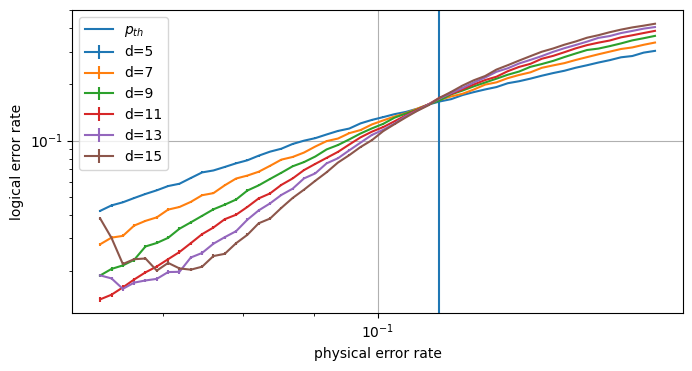

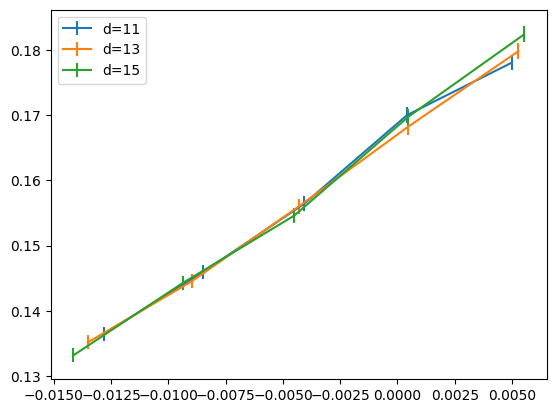

<Figure size 640x480 with 0 Axes>

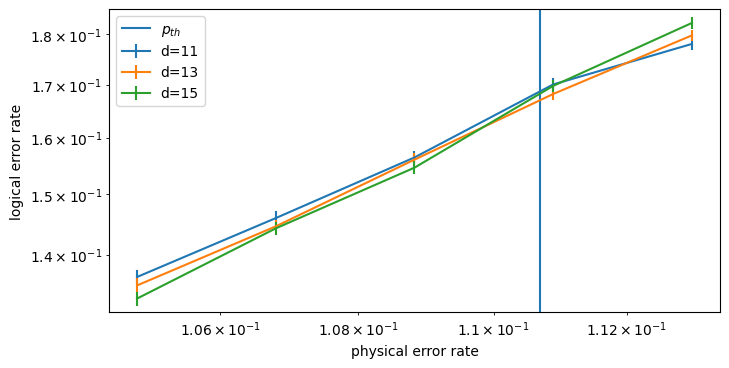

[0.11069829]
[3.08622649]


In [ ]:
folder_name = folder_name_ML_Z
p_window = 0.005
min_distance = 9 

g_pth = 0.1085
g_nu = 1.5

result = analysis_pipeline(
    folder_name,
    guess_pth = [g_pth],
    guess_nu = [g_nu],
    min_distance= min_distance, 
    min_noise_rate = g_pth - p_window,
    max_noise_rate = g_pth + p_window,
    )

print(result["p_threshold"])
print(result["nu_fit"])
results_ML_Z = result


       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.8570771847617318
             x: [ 1.095e-01  7.276e-01]
           nit: 57
          nfev: 115
 final_simplex: (array([[ 1.095e-01,  7.276e-01],
                       [ 1.095e-01,  7.276e-01],
                       [ 1.095e-01,  7.276e-01]]), array([ 8.571e-01,  8.571e-01,  8.571e-01]))


<Figure size 640x480 with 0 Axes>

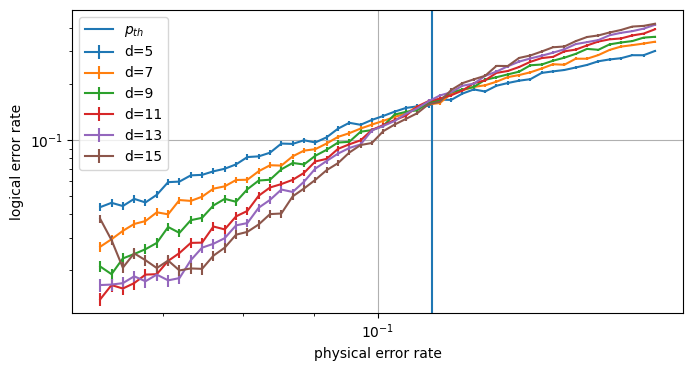

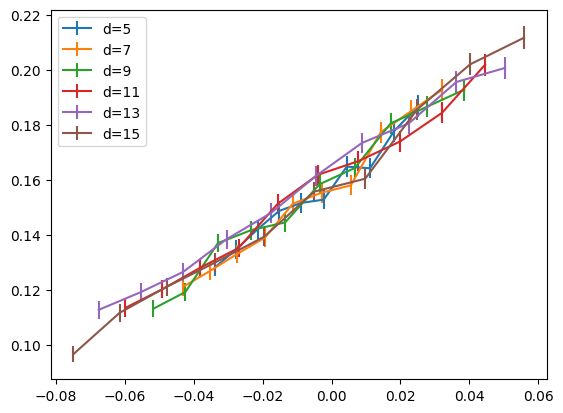

<Figure size 640x480 with 0 Axes>

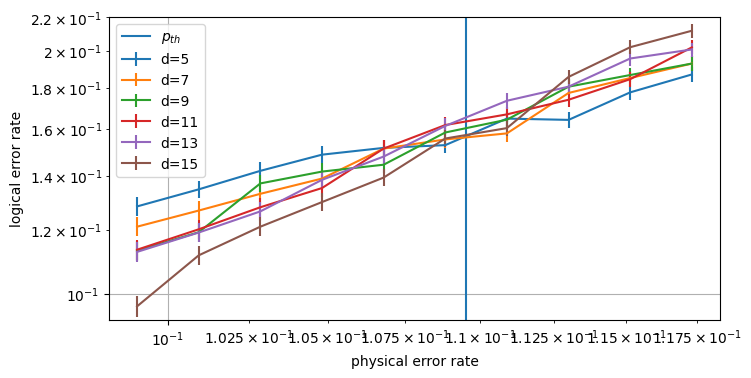

[0.10952941]
[1.37429753]


In [50]:
folder_name = folder_name_ML_X 
p_window = 0.01 
min_distance = 5

g_pth = 0.1085
g_nu = 1.5

result = analysis_pipeline(
    folder_name = folder_name,
    guess_pth = [g_pth],
    guess_nu = [g_nu],
    min_distance= min_distance, 
    min_noise_rate = g_pth - p_window,
    max_noise_rate = g_pth + p_window,
    )

print(result["p_threshold"])
print(result["nu_fit"])
results_ML_X = result


       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 1.1295525621324094
             x: [ 1.029e-01  6.577e-01]
           nit: 48
          nfev: 92
 final_simplex: (array([[ 1.029e-01,  6.577e-01],
                       [ 1.029e-01,  6.576e-01],
                       [ 1.029e-01,  6.577e-01]]), array([ 1.130e+00,  1.130e+00,  1.130e+00]))


<Figure size 640x480 with 0 Axes>

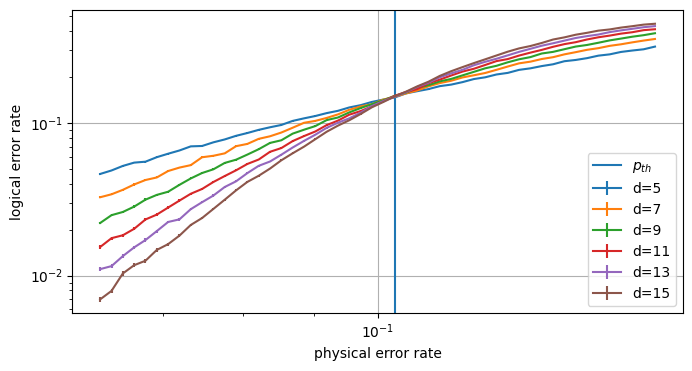

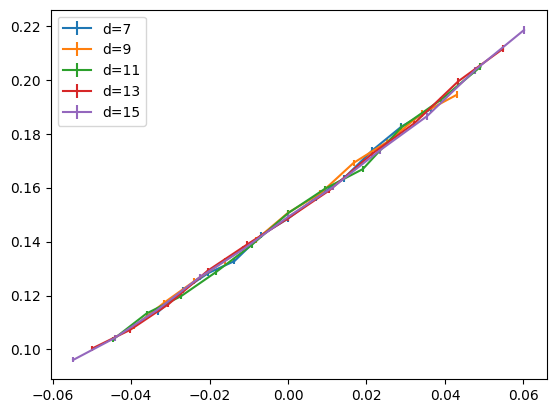

<Figure size 640x480 with 0 Axes>

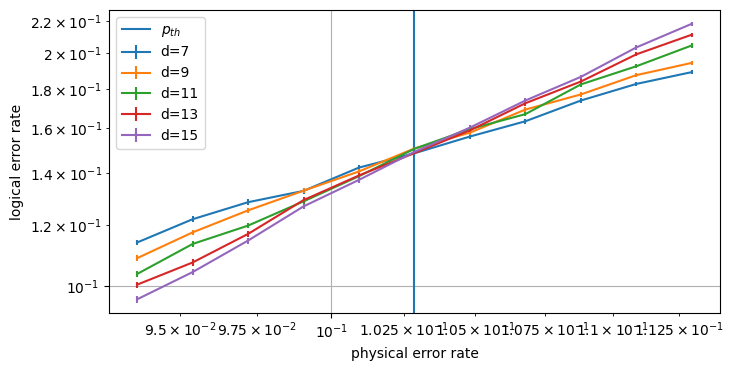

[0.10285962]
[1.52054879]


In [55]:
folder_name = folder_name_MWPM_Z 
p_window = 0.01 
min_distance = 7

g_pth = 0.103
g_nu = 1.5

result = analysis_pipeline(
    folder_name = folder_name,
    guess_pth = [g_pth],
    guess_nu = [g_nu],
    min_distance= min_distance, 
    min_noise_rate = g_pth - p_window,
    max_noise_rate = g_pth + p_window,
    )

print(result["p_threshold"])
print(result["nu_fit"])
results_MWPM_Z= result


       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.7260964236728874
             x: [ 1.035e-01  6.343e-01]
           nit: 35
          nfev: 66
 final_simplex: (array([[ 1.035e-01,  6.343e-01],
                       [ 1.035e-01,  6.343e-01],
                       [ 1.035e-01,  6.343e-01]]), array([ 7.261e-01,  7.261e-01,  7.261e-01]))


<Figure size 640x480 with 0 Axes>

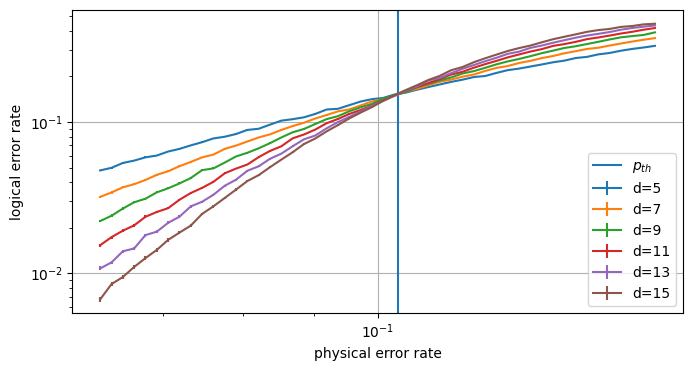

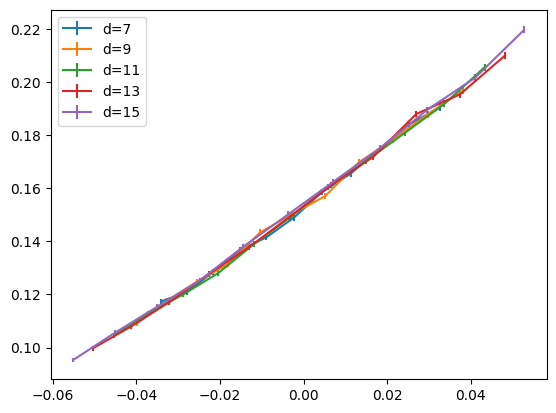

<Figure size 640x480 with 0 Axes>

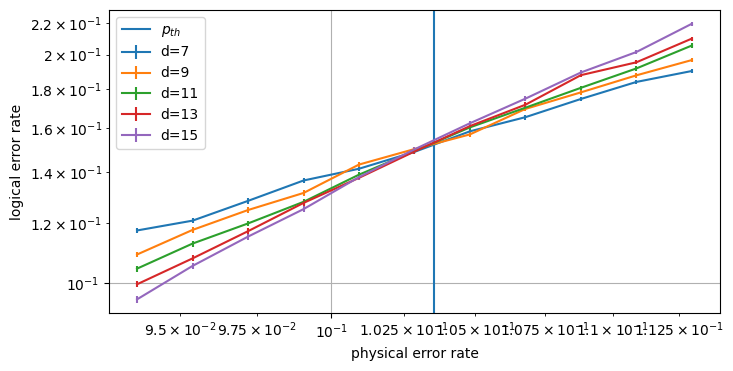

[0.10353042]
[1.57647397]


In [56]:
folder_name = folder_name_MWPM_X 
p_window = 0.01 
min_distance = 7

g_pth = 0.103
g_nu = 1.5

result = analysis_pipeline(
    folder_name = folder_name,
    guess_pth = [g_pth],
    guess_nu = [g_nu],
    min_distance= min_distance, 
    min_noise_rate = g_pth - p_window,
    max_noise_rate = g_pth + p_window,
    )

print(result["p_threshold"])
print(result["nu_fit"])
results_MWPM_X = result